send finns: True
rec finns : True

Vald modell: Bohus
R_ref = 1.257525 Ω
alpha = 0.00403 1/K
T_ref = 20.0 °C


C:\Users\lundi\AppData\Local\Temp\ipykernel_159828\1110711590.py:99: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_159828\1110711590.py:99: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")



Joined dataframe:
rows: 7669
start: 2025-12-11 15:25:02.469999 slut: 2025-12-11 15:27:32.450000
fs = 50.00250012500625 Hz
smooth_window = 100


,Mode,Delta_deg,Phase,P_send_mean_W,P_rec_mean_W,P_loss_mean_W,R_mean_Ohm,R_std_Ohm,T_mean_C,T_std_C,dU_mean_deg,dI_mean_deg,Key
0,common_station,-1.0,L1,1.546604e+07,1.524867e+07,217378.508796,6.005205,0.303176,956.827787,59.823635,1.898770,1.984417,common_station_-1.0deg
1,common_station,-1.0,L2,1.627749e+07,1.605842e+07,219072.667968,5.442087,0.301176,845.711461,59.429004,1.875989,1.954564,common_station_-1.0deg
2,common_station,-1.0,L3,1.551126e+07,1.527066e+07,240606.502038,6.567829,0.443940,1067.846628,87.599648,1.898759,2.459783,common_station_-1.0deg
3,common_station,-0.5,L1,1.546604e+07,1.524867e+07,217378.508796,6.005205,0.303176,956.827787,59.823635,1.398770,1.484417,common_station_-0.5deg
4,common_station,-0.5,L2,1.627749e+07,1.605842e+07,219072.667968,5.442087,0.301176,845.711461,59.429004,1.375989,1.454564,common_station_-0.5deg
5,common_station,-0.5,L3,1.551126e+07,1.527066e+07,240606.502038,6.567829,0.443940,1067.846628,87.599648,1.398759,1.959783,common_station_-0.5deg
6,common_station,-0.2,L1,1.546604e+07,1.524867e+07,217378.508796,6.005205,0.303176,956.827787,59.823635,1.098770,1.184417,common_station_-0.2deg
7,common_station,-0.2,L2,1.627749e+07,1.605842e+07,219072.667968,5.442087,0.301176,845.711461,59.429004,1.075989,1.154564,common_station_-0.2deg
8,common_station,-0.2,L3,1.551126e+07,1.527066e+07,240606.502038,6.567829,0.443940,1067.846628,87.599648,1.098759,1.659783,common_station_-0.2deg
9,common_station,-0.1,L1,1.546604e+07,1.524867e+07,217378.508796,6.005205,0.303176,956.827787,59.823635,0.998770,1.084417,common_station_-0.1deg



Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\bohus_power_angle_offset_sweep_effekt_metoden


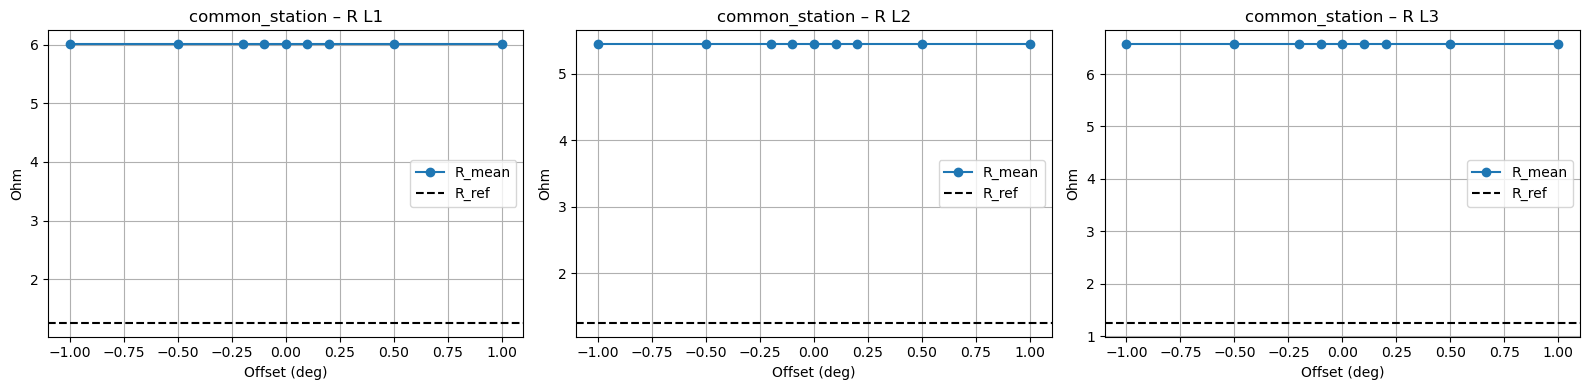

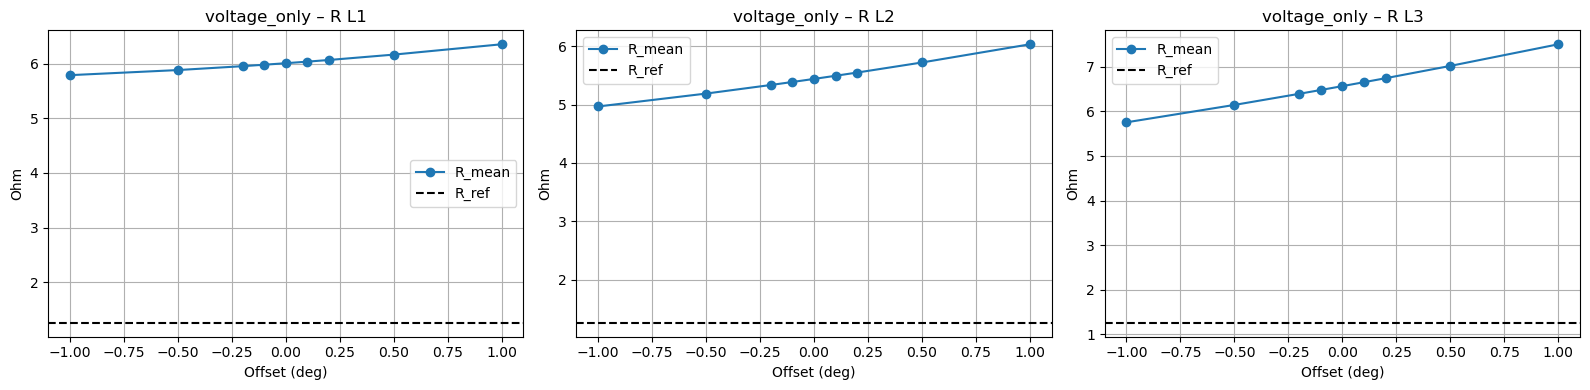

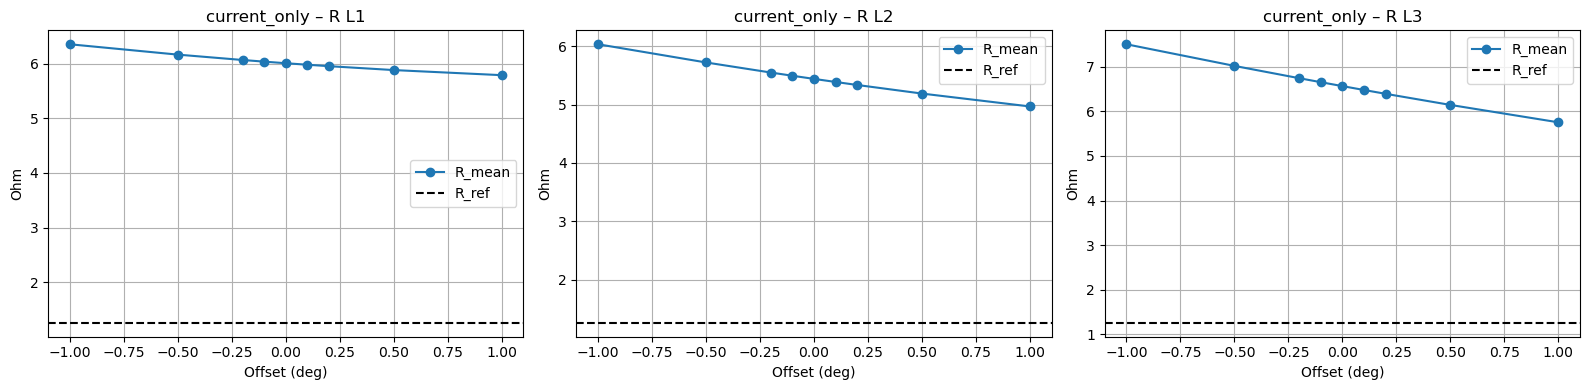

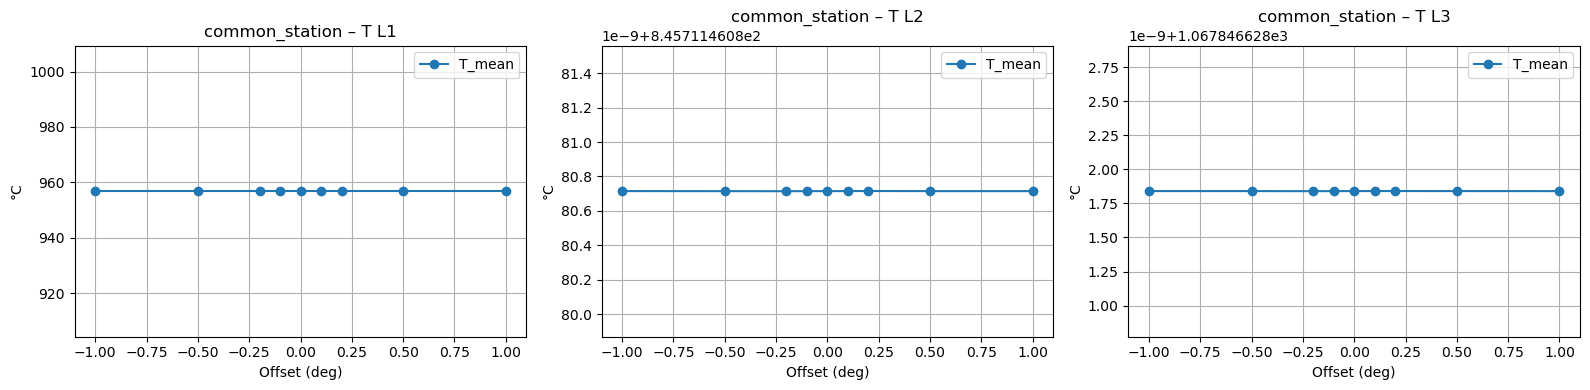

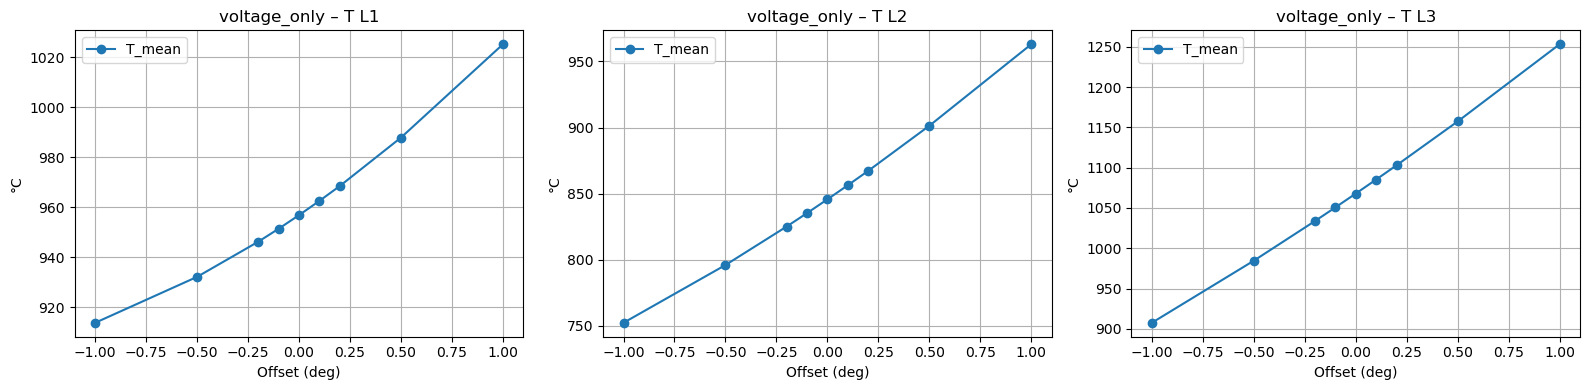

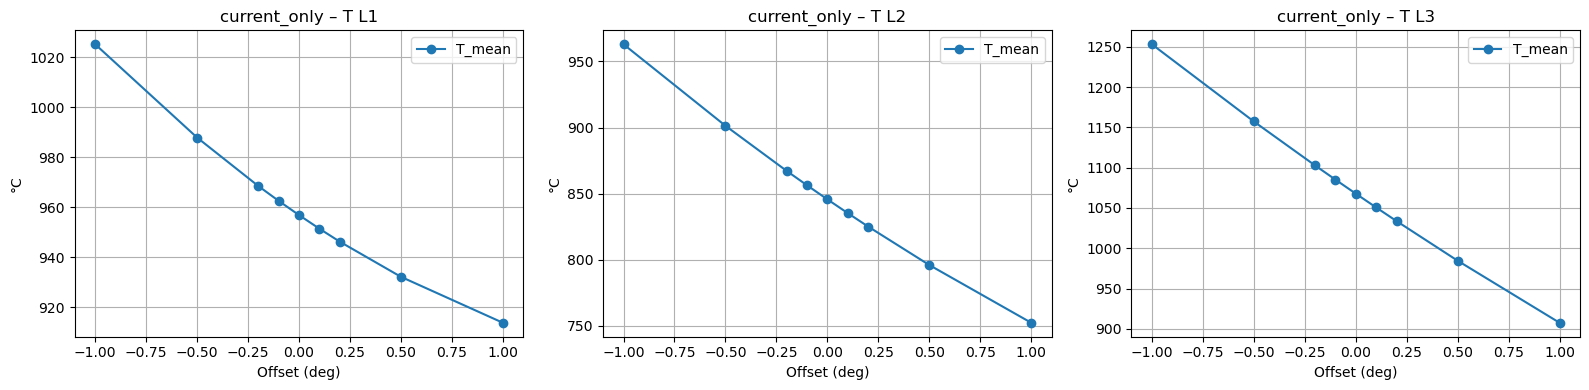

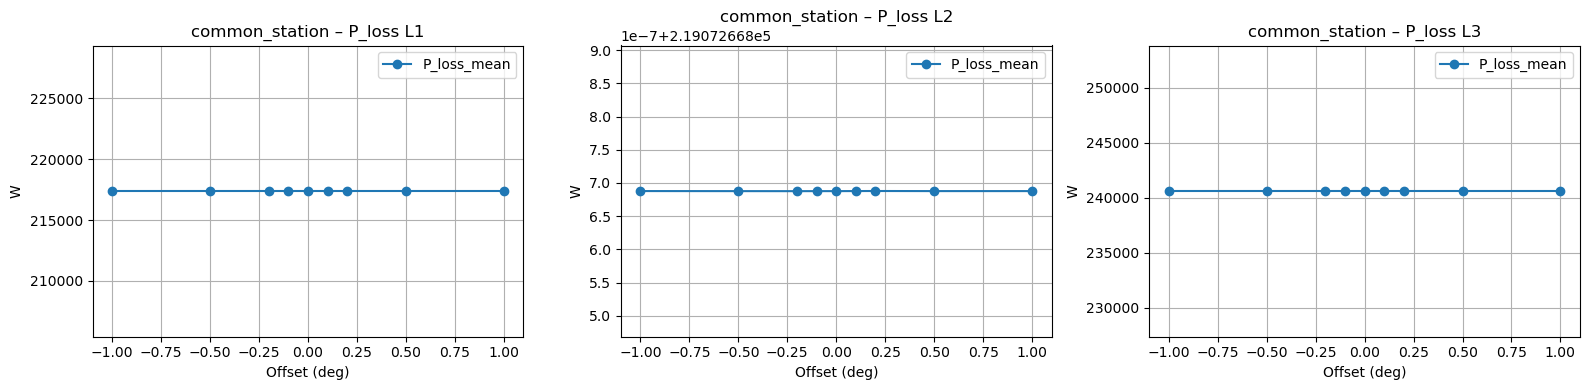

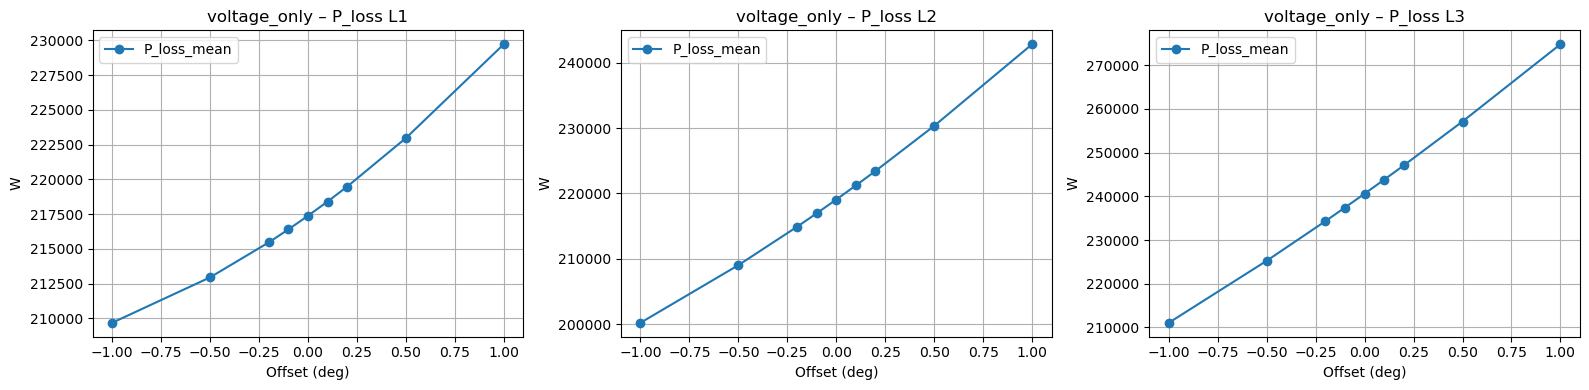

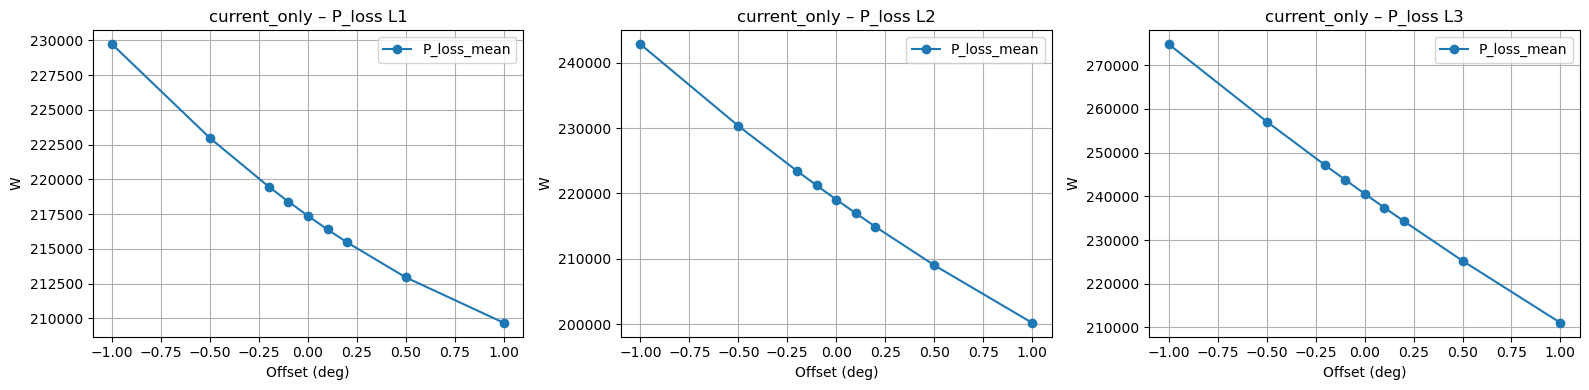

In [1]:
# ============================================================
# EFFEKTMETOD: OFFSET-SWEEP
# P_send / P_rec -> P_loss -> R -> T
# Syfte:
#   jämföra common_station / voltage_only / current_only
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_file  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_file.exists())
print("rec finns :", rec_file.exists())

# ============================================================
# MODELLVAL
# ============================================================

MODEL = "Bohus"   # byt till "Gota" om du vill

MODELS = {
    "Bohus": {
        "length_km": 17.25,
        "RAC_ohm_per_km": 0.0729,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
    },
    "Gota": {
        "length_km": 21.95,
        "RAC_ohm_per_km": 0.0348,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
    },
}

model = MODELS[MODEL]
R_ref = model["RAC_ohm_per_km"] * model["length_km"]
alpha = model["alpha"]
T_ref = model["T_ref_C"]

print(f"\nVald modell: {MODEL}")
print(f"R_ref = {R_ref:.6f} Ω")
print(f"alpha = {alpha:.5f} 1/K")
print(f"T_ref = {T_ref:.1f} °C")

# ============================================================
# PARAMETRAR
# ============================================================

smooth_seconds = 2.0
delta_list = [-1.0, -0.5, -0.2, -0.1, 0.0, 0.1, 0.2, 0.5, 1.0]

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None)
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def rolling_real_mean(x, window):
    return pd.Series(x, index=x.index).rolling(window=window, center=True, min_periods=1).mean()

def build_joined_dataframe():
    keyS = read_key_table_safe(send_file, keyS_sheet)
    keyR = read_key_table_safe(rec_file, keyR_sheet)

    send = read_data_table_safe(send_file, dataS_sheet)
    rec  = read_data_table_safe(rec_file, dataR_sheet)

    send = send.merge(keyS, on="ID", how="inner")
    rec  = rec.merge(keyR, on="ID", how="inner")

    wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
    wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

    wideS = wideS.add_suffix("_S").sort_index()
    wideR = wideR.add_suffix("_R").sort_index()

    df_joined = wideS.join(wideR, how="inner").copy()

    required_cols = []
    for ph in ["L1", "L2", "L3"]:
        required_cols += [
            f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
            f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
        ]

    missing = [c for c in required_cols if c not in df_joined.columns]
    if missing:
        raise ValueError(f"Saknade kolumner: {missing}")

    df_joined = df_joined.dropna(subset=required_cols).copy()

    # filtrera bort orimliga vinkelvärden
    angle_cols = [c for c in df_joined.columns if "ANG" in c]
    for c in angle_cols:
        df_joined = df_joined[(df_joined[c] >= -180) & (df_joined[c] <= 180)]

    return df_joined

# ============================================================
# BYGG DATASET
# ============================================================

df_joined = build_joined_dataframe()

dt = df_joined.index.to_series().diff().dropna().dt.total_seconds()
fs = 1.0 / dt.median()
smooth_window = int(round(smooth_seconds * fs))

print("\nJoined dataframe:")
print("rows:", len(df_joined))
print("start:", df_joined.index.min(), "slut:", df_joined.index.max())
print("fs =", fs, "Hz")
print("smooth_window =", smooth_window)

# ============================================================
# KÖR ETT SCENARIO
# ============================================================

def run_power_offset_scenario(df_joined, delta_deg=0.0, mode="common_station"):
    """
    mode:
      - common_station: samma delta på U_R och I_R
      - voltage_only: delta bara på U_R
      - current_only: delta bara på I_R
    """

    out = pd.DataFrame(index=df_joined.index)
    summary_rows = []

    for ph in ["L1", "L2", "L3"]:
        U_mag_S = df_joined[f"U{ph}MAG_S"]
        U_ang_S = df_joined[f"U{ph}ANG_S"]
        U_mag_R = df_joined[f"U{ph}MAG_R"]
        U_ang_R = df_joined[f"U{ph}ANG_R"]

        I_mag_S = df_joined[f"I{ph}MAG_S"]
        I_ang_S = df_joined[f"I{ph}ANG_S"]
        I_mag_R = df_joined[f"I{ph}MAG_R"]
        I_ang_R = df_joined[f"I{ph}ANG_R"]

        # Korrigerad mottagarströmvinkel
        I_ang_R_corr = wrap_angle_deg(I_ang_R + 180.0)

        if mode == "common_station":
            U_ang_R_use = wrap_angle_deg(U_ang_R + delta_deg)
            I_ang_R_use = wrap_angle_deg(I_ang_R_corr + delta_deg)

        elif mode == "voltage_only":
            U_ang_R_use = wrap_angle_deg(U_ang_R + delta_deg)
            I_ang_R_use = I_ang_R_corr.copy()

        elif mode == "current_only":
            U_ang_R_use = U_ang_R.copy()
            I_ang_R_use = wrap_angle_deg(I_ang_R_corr + delta_deg)

        else:
            raise ValueError("mode måste vara common_station, voltage_only eller current_only")

        Vs = complex_from_mag_ang(U_mag_S, U_ang_S)
        Vr = complex_from_mag_ang(U_mag_R, U_ang_R_use)

        Is = complex_from_mag_ang(I_mag_S, I_ang_S)
        Ir = complex_from_mag_ang(I_mag_R, I_ang_R_use)

        # Aktiv effekt per station
        P_send = np.real(Vs * np.conj(Is))
        P_rec  = np.real(Vr * np.conj(Ir))

        # Effektförlust: här använder vi konsekvent P_send - P_rec
        # eftersom vi vill testa den "klassiska" effektmetoden
        P_loss = P_send - P_rec

        # smoothe förlust och ström
        P_loss_sm = rolling_real_mean(pd.Series(P_loss, index=df_joined.index), smooth_window)
        I_eff2_sm = rolling_real_mean(pd.Series((np.abs(Is)**2 + np.abs(Ir)**2) / 2.0, index=df_joined.index), smooth_window)

        R_est = P_loss_sm / I_eff2_sm
        T_est = ((R_est / R_ref) - 1.0) / alpha + T_ref

        dU = wrap_angle_deg(U_ang_S - U_ang_R_use)
        dI = wrap_angle_deg(I_ang_S - I_ang_R_use)

        out[f"P_send_{ph}"] = P_send
        out[f"P_rec_{ph}"] = P_rec
        out[f"P_loss_{ph}"] = P_loss_sm
        out[f"R_{ph}"] = R_est
        out[f"T_{ph}"] = T_est
        out[f"ΔU_{ph}"] = dU
        out[f"ΔI_{ph}"] = dI

        summary_rows.append({
            "Mode": mode,
            "Delta_deg": delta_deg,
            "Phase": ph,
            "P_send_mean_W": np.nanmean(P_send),
            "P_rec_mean_W": np.nanmean(P_rec),
            "P_loss_mean_W": np.nanmean(P_loss_sm),
            "R_mean_Ohm": np.nanmean(R_est),
            "R_std_Ohm": np.nanstd(R_est),
            "T_mean_C": np.nanmean(T_est),
            "T_std_C": np.nanstd(T_est),
            "dU_mean_deg": circular_mean_deg(dU),
            "dI_mean_deg": circular_mean_deg(dI),
        })

    summary_df = pd.DataFrame(summary_rows)
    return out, summary_df

# ============================================================
# KÖR SWEEPEN
# ============================================================

all_results = []
all_outputs = {}

for mode in ["common_station", "voltage_only", "current_only"]:
    for delta in delta_list:
        key = f"{mode}_{delta:+.1f}deg"
        out_tmp, summary_tmp = run_power_offset_scenario(df_joined, delta_deg=delta, mode=mode)
        summary_tmp["Key"] = key
        all_results.append(summary_tmp)
        all_outputs[key] = out_tmp

summary_all = pd.concat(all_results, ignore_index=True)
display(summary_all.head(15))

# ============================================================
# SPARA
# ============================================================

VERSION = "bohus_power_angle_offset_sweep_effekt_metoden"
output_dir = send_file.parent / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

summary_all.to_excel(output_dir / "summary_power_angle_offset_sweep.xlsx", index=False)
summary_all.to_csv(output_dir / "summary_power_angle_offset_sweep.csv", index=False)

print("\nSparat till:", output_dir)

# ============================================================
# PLOTTAR: R vs delta
# ============================================================

for mode in ["common_station", "voltage_only", "current_only"]:
    fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

    for i, ph in enumerate(["L1", "L2", "L3"]):
        tmp = summary_all[(summary_all["Mode"] == mode) & (summary_all["Phase"] == ph)].sort_values("Delta_deg")
        axs[i].plot(tmp["Delta_deg"], tmp["R_mean_Ohm"], marker="o", label="R_mean")
        axs[i].axhline(R_ref, color="black", linestyle="--", label="R_ref")
        axs[i].set_title(f"{mode} – R {ph}")
        axs[i].set_xlabel("Offset (deg)")
        axs[i].set_ylabel("Ohm")
        axs[i].grid(True)
        axs[i].legend()

    fig.tight_layout()
    fig.savefig(output_dir / f"plot_R_vs_delta_{mode}.png", dpi=200)
    plt.show()

# ============================================================
# PLOTTAR: T vs delta
# ============================================================

for mode in ["common_station", "voltage_only", "current_only"]:
    fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

    for i, ph in enumerate(["L1", "L2", "L3"]):
        tmp = summary_all[(summary_all["Mode"] == mode) & (summary_all["Phase"] == ph)].sort_values("Delta_deg")
        axs[i].plot(tmp["Delta_deg"], tmp["T_mean_C"], marker="o", label="T_mean")
        axs[i].set_title(f"{mode} – T {ph}")
        axs[i].set_xlabel("Offset (deg)")
        axs[i].set_ylabel("°C")
        axs[i].grid(True)
        axs[i].legend()

    fig.tight_layout()
    fig.savefig(output_dir / f"plot_T_vs_delta_{mode}.png", dpi=200)
    plt.show()

# ============================================================
# PLOTTAR: P_loss vs delta
# ============================================================

for mode in ["common_station", "voltage_only", "current_only"]:
    fig, axs = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

    for i, ph in enumerate(["L1", "L2", "L3"]):
        tmp = summary_all[(summary_all["Mode"] == mode) & (summary_all["Phase"] == ph)].sort_values("Delta_deg")
        axs[i].plot(tmp["Delta_deg"], tmp["P_loss_mean_W"], marker="o", label="P_loss_mean")
        axs[i].set_title(f"{mode} – P_loss {ph}")
        axs[i].set_xlabel("Offset (deg)")
        axs[i].set_ylabel("W")
        axs[i].grid(True)
        axs[i].legend()

    fig.tight_layout()
    fig.savefig(output_dir / f"plot_Ploss_vs_delta_{mode}.png", dpi=200)
    plt.show()